### Lab 1: `Chromakey` using `bitwise operations and mask`

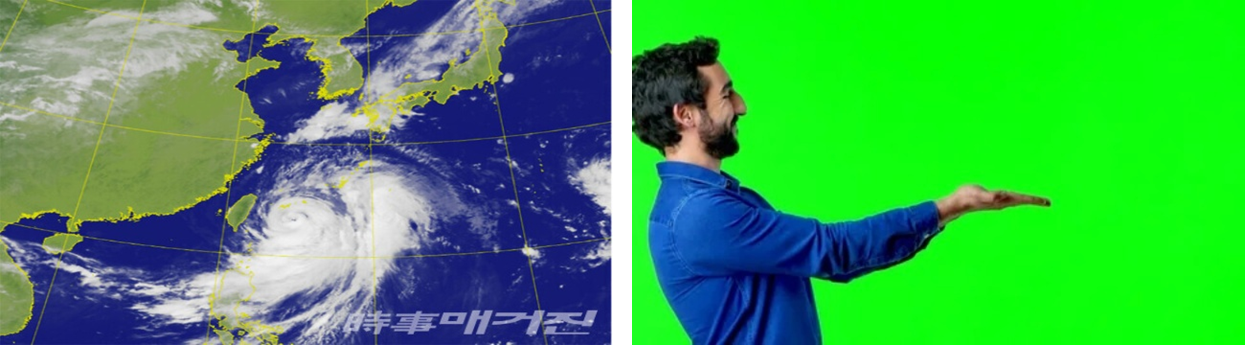


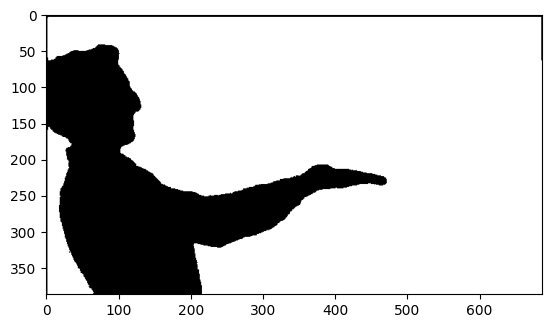

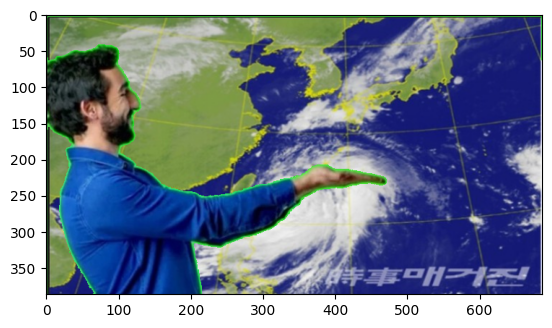

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_bg = cv2.imread("images/chroma_bg.jpg")
img_fg = cv2.imread("images/chroma_fg.jpg")

img_bg = cv2.resize(img_bg, (img_fg.shape[1], img_fg.shape[0]))

# bgr
b = img_fg[:, :, 0]
g = img_fg[:, :, 1]
r = img_fg[:, :, 2]

thr = 230

# 초록 배경 검출
mask = (g > thr) & (b < thr) & (r < thr)
mask = mask.astype(np.uint8) * 255
mask = mask[:,:, np.newaxis]

plt.imshow(mask, cmap='gray')
plt.show()

result = (img_fg & (~mask)) | (img_bg & mask)

plt.imshow(result[:, :, ::-1])
plt.show()

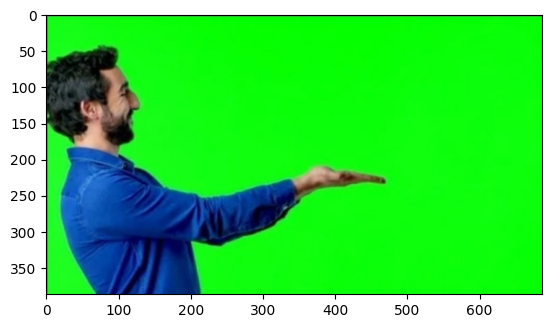

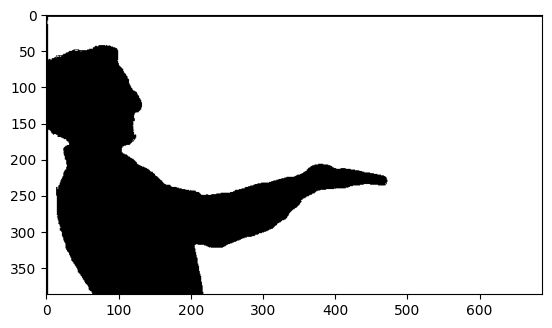

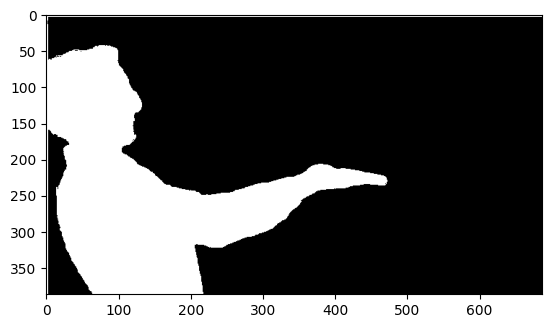

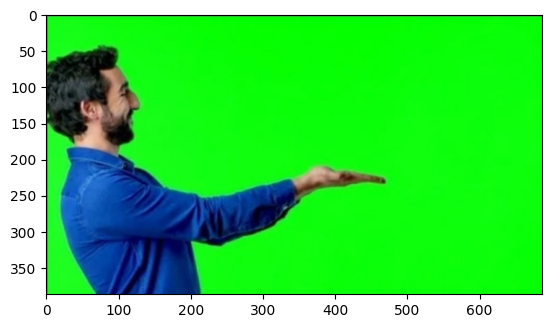

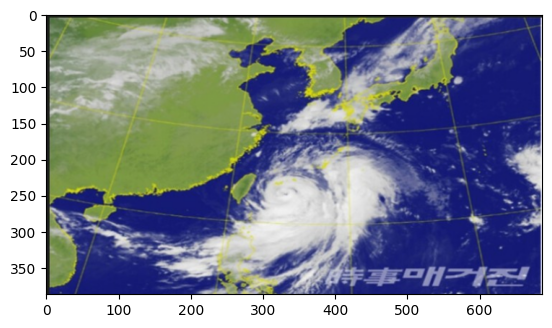

In [3]:
import numpy as np, cv2
import matplotlib.pyplot as plt

img_bg = cv2.imread("images/chroma_bg.jpg")
img_fg  = cv2.imread("images/chroma_fg.jpg")

img_bg = cv2.resize(img_bg, img_fg.shape[:2][::-1])

plt.imshow(img_fg[:,:,::-1])
plt.show()

# 1. Find the pixels that should be removed, green
# rgb 가 range 에 들어가는지 검사, r(0~100) g(200~255), b(0~50) 
# uint8, 0 or 255 로 나옴
idx_removed = cv2.inRange(img_fg, (0, 200, 0), (50, 255, 50) )

plt.imshow(idx_removed, cmap='gray')
plt.show()

# 2. Mask for foreground
mask_fg = cv2.bitwise_not(idx_removed)
plt.imshow(mask_fg, cmap='gray')
plt.show()

# 3. Apply the mask to the foreground
fg = cv2.bitwise_and(img_fg, img_fg, mask_fg)
plt.imshow(fg[:,:,::-1]) # BGR -> RGB
plt.show()

# 4. Generate the mask for the background
mask_bg = idx_removed

# 5. Apply the mask to the background
bg = cv2.bitwise_and(img_bg, img_bg, mask_bg)
plt.imshow(bg[:,:,::-1])
plt.show()

# 6. Merge the fg and bg


### Lab 2: `Image merging`(chromakey) using `bitwise operations and mask`
    - `cv2.inRange` returns `0 or 255, unint8`

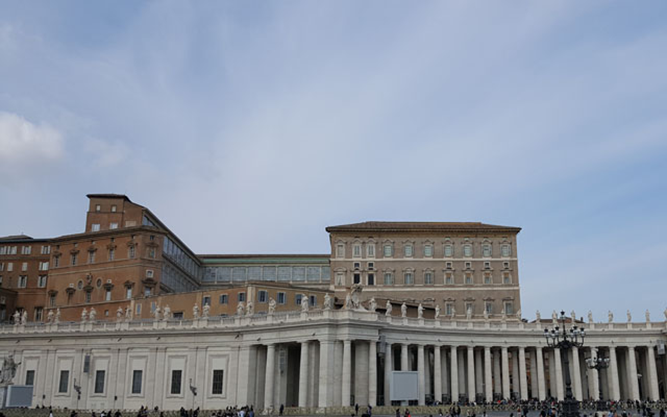 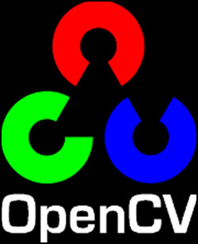

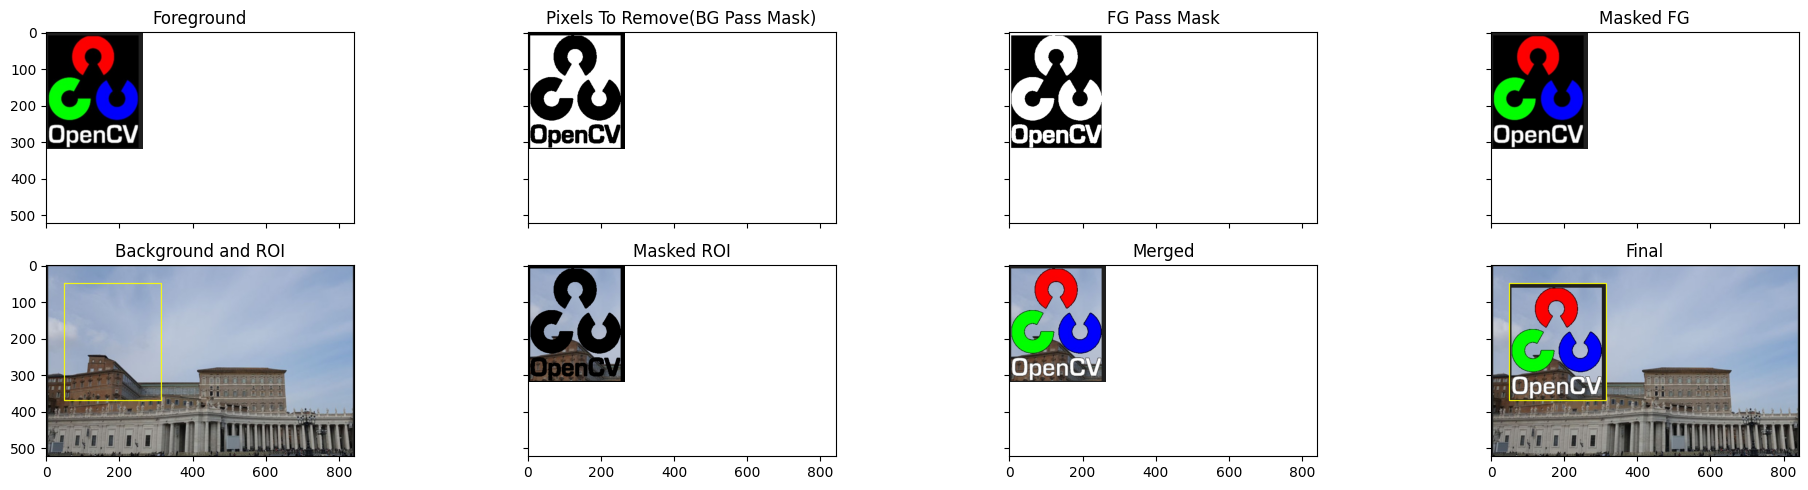

In [2]:
import numpy as np, cv2
import matplotlib.pyplot as plt

#---- Step 1: Load the background and foreground images
image = cv2.imread("images/bit_test.jpg")
logo  = cv2.imread("images/logo.jpg")

#---- Step 2: Create masks for chroma keying. Black pixels in the logo will be removed, and the rest will be kept.
bg_pass_mask = cv2.inRange(logo, (0, 0, 0), (20,20,20) )
fg_pass_mask = cv2.bitwise_not(bg_pass_mask)

#---- Step 3: Extract the foreground and background from the logo
fg = cv2.bitwise_and(logo, logo, mask=fg_pass_mask)

#---- Step 4: Extract the region of interest (roi) in the background image
(h, w) = logo.shape[:2]         # 로고 영상 크기
x, y = 50, 50                   # 로고를 배치할 위치 (x, y) 
roi = image[y:y+h, x:x+w]

#---- Step 5: Mask the roi to get the background where the logo will be placed
bg = cv2.bitwise_and(roi, roi, mask=bg_pass_mask)

#---- Step 6: Add the masked foreground and background
merged = cv2.add(bg, fg)

#-- Step 7: Place the merged image back into the original image
final = image.copy()
final[y:y+h, x:x+w] = merged

fig, axes = plt.subplots(2, 4, figsize = (20, 5), sharex=True, sharey=True)
axes[0,0].imshow(logo[:,:,::-1])
axes[0,0].set_title('Foreground')
axes[0,1].imshow(bg_pass_mask, cmap='gray')
axes[0,1].set_title('Pixels To Remove(BG Pass Mask)')
axes[0,2].imshow(fg_pass_mask, cmap='gray')
axes[0,2].set_title('FG Pass Mask')
axes[0,3].imshow(fg[:,:,::-1])
axes[0,3].set_title('Masked FG')

image_roi = cv2.rectangle(image, (x,y) ,(x+w, y+h), color=[0, 255, 255], thickness=2)
axes[1,0].imshow(image_roi[:,:,::-1])
axes[1,0].set_title('Background and ROI')
axes[1,1].imshow(bg[:,:,::-1], cmap='gray')
axes[1,1].set_title('Masked ROI')
axes[1,2].imshow(merged[:,:,::-1])
axes[1,2].set_title('Merged')
final_roi = cv2.rectangle(final, (x,y) ,(x+w, y+h), color=[0, 255, 255], thickness=2)
axes[1,3].imshow(final_roi[:,:,::-1])
axes[1,3].set_title('Final')

plt.tight_layout()
plt.show()